In [1]:
import csv
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
def mean(array) -> float:
    if len(array) == 0: return 0.0
    return sum(array) / len(array)

class TrafficAnalyzer:
    possible_models = ["equal", "poisson"]

    def __init__(self, csv_path, sim_time, model_name=None):
        self.csv_path = Path(csv_path)
        self.sim_time = sim_time
        self.model_name = model_name
        if model_name is None:
            self._detect_model_name()

        self.arrival_times = []
        self.packet_sizes = []
        self.delays = []

        self._parse_parameters_from_csv()
        self._calc_delays()

    def _parse_parameters_from_csv(self):
        with open(self.csv_path, "r", newline="") as file:
            reader = csv.reader(file)
        
            for line in reader:
                self.arrival_times.append(float(line[0]))
                self.packet_sizes.append(int(line[1]))

    def _calc_delays(self):
        for i in range(1, len(self.arrival_times)):
            self.delays.append(self.arrival_times[i] - self.arrival_times[i-1])

    def _detect_model_name(self):
        if self.csv_path.parent.name in self.possible_models:
            self.model_name = self.csv_path.parent.name
        else: self.model_name = "unknown"

    def packet_mean(self) -> float:
        return mean(self.packet_sizes)

    def mean_bitrate(self) -> float:
        return sum(self.packet_sizes) / self.sim_time

    def mean_delay(self) -> float:
        return mean(self.delays)

    def delay_hist(self, bins=20):
        plt.figure(figsize=(10, 6))
        plt.hist(self.delays, bins=bins, color='forestgreen', alpha=1.0)
        plt.xlabel("Delay")
        plt.ylabel("Count")
        plt.title("Delay histogram")
        plt.gca().set_axisbelow(True)
        plt.grid(True, color='black', linestyle='--', linewidth=0.5, alpha=0.7)
        plt.show()

    def packet_size_hist(self, bins=20):
        plt.figure(figsize=(10, 6))
        plt.hist(self.packet_sizes, bins=bins, color='navy', alpha=1.0)
        plt.xlabel("Packet size")
        plt.ylabel("Count")
        plt.title("Packet size histogram")
        plt.gca().set_axisbelow(True)
        plt.grid(True, color='black', linestyle='--', linewidth=0.5, alpha=0.7)
        plt.show()
    
    def auto_analyse(self, delay_hist_bins=20, pack_size_bins=20):
        print(
            f"Traffic model: {self.model_name}\n" +
            f"Mean packet size: {self.packet_mean()}\n" +
            f"Mean bitrate: {self.mean_bitrate()}\n" +
            f"Mean delay: {self.mean_delay()}\n"
        )
        self.delay_hist(bins=delay_hist_bins)
        self.packet_size_hist(bins=pack_size_bins)

Traffic model: poisson
Mean packet size: 5.0
Mean bitrate: 1.08
Mean delay: 10.177570093457945



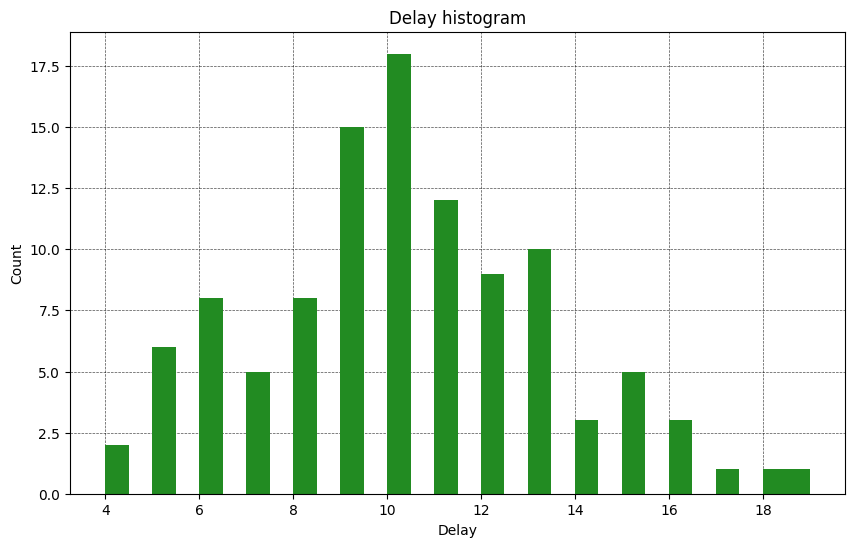

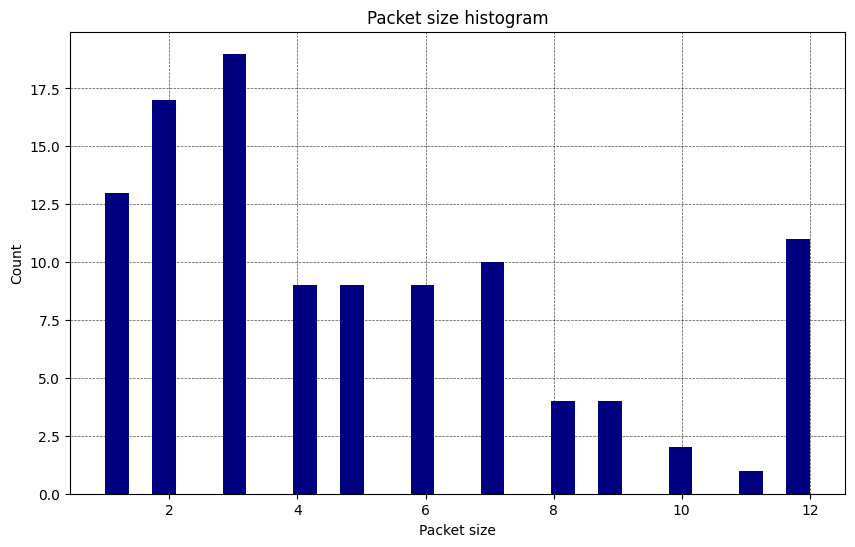

In [12]:
filename = "data/poisson/test_poisson2_simtime_1100.0_traffic.csv"
model = TrafficAnalyzer(filename, 500)
model.auto_analyse(delay_hist_bins=30, pack_size_bins=30)